In [1]:
import pandas as pd
import numpy as np

#ignore warnings
import warnings 
warnings.filterwarnings('ignore')

#data processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#classification models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

#model evaluation
from sklearn.metrics import classification_report, roc_auc_score, precision_score

In [2]:
donors = pd.read_csv('donor.csv')
hospitals = pd.read_csv('Hospital.csv')
donors.head()

,donor_id,age,gender,blood_group,rhesus_factor,state,lga,availability,health_status,last_donation_date,eligible_to_donate
0,D100000,56,Male,A,-,Ogun,Mushin,Unavailable,Healthy,2025-03-27,No
1,D100001,46,Male,A,+,Rivers,Surulere,Unavailable,Healthy,2025-05-29,No
2,D100002,32,Female,O,+,Oyo,Eti-Osa,Available,Healthy,2026-01-07,Yes
3,D100003,25,Female,A,+,Rivers,Lekki,Unavailable,Healthy,2026-04-25,No
4,D100004,38,Male,B,-,Ogun,Ikeja,Available,Healthy,2025-05-31,Yes


In [3]:
hospitals.head()

,hospital_id,hospital_name,ownership_type,hospital_type,lga,address,total_beds,emergency_level,latitude,longitude,...,o+,o-,number_of_doctors,number_of_nurses,year_established,operating_status,hmo_accepted,emergency_service,remarks,state
0,HSP0001,Lagoon Medical Clinic,Private,Specialist,Apapa,"11 Wharf Road, Apapa, Lagos",NaN,NaN,6.640370,3.022458,...,0,0,6,41,2022,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN
1,HSP0002,Royal Health Medical Centre,Private,Maternity,Agege,"136 Iju Road, Agege, Lagos",NaN,NaN,6.426414,3.446246,...,0,0,57,179,2021,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN
2,HSP0003,Prime Care Clinic,Private,Multi-specialist,Alimosho,"1 Egbeda Road, Alimosho, Lagos",NaN,NaN,6.576825,3.346292,...,166,24,65,15,1998,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN
3,HSP0004,Life Integrated Health Centre,Private,Multi-specialist,Ifako-Ijaiye,"19 Iju Road, Ifako-Ijaiye, Lagos",NaN,NaN,6.561733,3.083357,...,111,9,22,94,1995,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN
4,HSP0005,Pearl Specialist Hospital,Private,Maternity,Ajeromi-Ifelodun,"73 Kirikiri Road, Ajeromi-Ifelodun, Lagos",NaN,NaN,6.477993,3.541460,...,0,0,78,17,2007,Active,Yes,24 Hours,Synthetic dataset for analysis,NaN


In [4]:
donors.info

<bound method DataFrame.info of     donor_id  age  gender blood_group rhesus_factor   state       lga  \
0    D100000   56    Male           A             -    Ogun    Mushin   
1    D100001   46    Male           A             +  Rivers  Surulere   
2    D100002   32  Female           O             +     Oyo   Eti-Osa   
3    D100003   25  Female           A             +  Rivers     Lekki   
4    D100004   38    Male           B             -    Ogun     Ikeja   
..       ...  ...     ...         ...           ...     ...       ...   
995  D100995   41  Female           A             +   Abuja    Mushin   
996  D100996   32    Male           O             -  Rivers    Mushin   
997  D100997   46  Female           A             +   Lagos     Lekki   
998  D100998   25    Male           O             +     Oyo    Kosofe   
999  D100999   22  Female           A             +     Oyo  Surulere   

    availability health_status last_donation_date eligible_to_donate  
0    Unavailable    

In [5]:
hospitals.info

<bound method DataFrame.info of     hospital_id                         hospital_name ownership_type  \
0       HSP0001                 Lagoon Medical Clinic        Private   
1       HSP0002           Royal Health Medical Centre        Private   
2       HSP0003                     Prime Care Clinic        Private   
3       HSP0004         Life Integrated Health Centre        Private   
4       HSP0005             Pearl Specialist Hospital        Private   
..          ...                                   ...            ...   
995     HSP0996                  Bridge Health Clinic        Private   
996     HSP0997  Royal Specialist Specialist Hospital        Private   
997     HSP0998                   Blue Medical Clinic        Private   
998     HSP0999      Cedar Family Specialist Hospital        Private   
999     HSP1000  Grace Diagnostic Specialist Hospital        Private   

        hospital_type               lga  \
0          Specialist             Apapa   
1           Mater

In [6]:
hospitals.describe

<bound method NDFrame.describe of     hospital_id                         hospital_name ownership_type  \
0       HSP0001                 Lagoon Medical Clinic        Private   
1       HSP0002           Royal Health Medical Centre        Private   
2       HSP0003                     Prime Care Clinic        Private   
3       HSP0004         Life Integrated Health Centre        Private   
4       HSP0005             Pearl Specialist Hospital        Private   
..          ...                                   ...            ...   
995     HSP0996                  Bridge Health Clinic        Private   
996     HSP0997  Royal Specialist Specialist Hospital        Private   
997     HSP0998                   Blue Medical Clinic        Private   
998     HSP0999      Cedar Family Specialist Hospital        Private   
999     HSP1000  Grace Diagnostic Specialist Hospital        Private   

        hospital_type               lga  \
0          Specialist             Apapa   
1           Mat

In [7]:
donors.columns

Index(['donor_id', 'age', 'gender', 'blood_group', 'rhesus_factor', 'state',
       'lga', 'availability', 'health_status', 'last_donation_date',
       'eligible_to_donate'],
      dtype='str')

In [8]:
hospitals.columns

Index(['hospital_id', 'hospital_name', 'ownership_type', 'hospital_type',
       'lga', 'address', 'total_beds', 'emergency_level', 'latitude',
       'longitude', 'blood_donation_centre', 'average_monthly_donors',
       'monthly_blood_units_collected', 'annual_blood_units_collected', 'a+',
       'a-', 'b+', 'b-', 'ab+', 'ab-', 'o+', 'o-', 'number_of_doctors',
       'number_of_nurses', 'year_established', 'operating_status',
       'hmo_accepted', 'emergency_service', 'remarks', 'state'],
      dtype='str')

In [9]:
donors.isnull().sum()

donor_id              0
age                   0
gender                0
blood_group           0
rhesus_factor         0
state                 0
lga                   0
availability          0
health_status         0
last_donation_date    0
eligible_to_donate    0
dtype: int64

In [10]:
hospitals.isnull().sum()

hospital_id                         0
hospital_name                       0
ownership_type                      0
hospital_type                       0
lga                                 0
address                             0
total_beds                       1000
emergency_level                  1000
latitude                            0
longitude                           0
blood_donation_centre               0
average_monthly_donors              0
monthly_blood_units_collected       0
annual_blood_units_collected        0
a+                                  0
a-                                  0
b+                                  0
b-                                  0
ab+                                 0
ab-                                 0
o+                                  0
o-                                  0
number_of_doctors                   0
number_of_nurses                    0
year_established                    0
operating_status                    0
hmo_accepted

## Handling missing values

In [11]:
cols_to_drop = ['total_beds', 'emergency_level', 'state']
hospitals = hospitals.drop(columns=cols_to_drop)

In [12]:
hospitals.isnull().sum()

hospital_id                      0
hospital_name                    0
ownership_type                   0
hospital_type                    0
lga                              0
address                          0
latitude                         0
longitude                        0
blood_donation_centre            0
average_monthly_donors           0
monthly_blood_units_collected    0
annual_blood_units_collected     0
a+                               0
a-                               0
b+                               0
b-                               0
ab+                              0
ab-                              0
o+                               0
o-                               0
number_of_doctors                0
number_of_nurses                 0
year_established                 0
operating_status                 0
hmo_accepted                     0
emergency_service                0
remarks                          0
dtype: int64

In [13]:
hospitals.dtypes

hospital_id                          str
hospital_name                        str
ownership_type                       str
hospital_type                        str
lga                                  str
address                              str
latitude                         float64
longitude                        float64
blood_donation_centre                str
average_monthly_donors             int64
monthly_blood_units_collected      int64
annual_blood_units_collected       int64
a+                                 int64
a-                                 int64
b+                                 int64
b-                                 int64
ab+                                int64
ab-                                int64
o+                                 int64
o-                                 int64
number_of_doctors                  int64
number_of_nurses                   int64
year_established                   int64
operating_status                     str
hmo_accepted    

In [14]:
 # 1. Convert Yes/No flags to 1/0
flag_cols = ['blood_donation_centre', 'hmo_accepted', 'emergency_service']
for col in flag_cols:
    hospitals[col] = hospitals[col].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})

# 2. Convert to category for memory + modeling
cat_cols = ['ownership_type', 'hospital_type', 
            'lga', 'operating_status', 'remarks']
hospitals[cat_cols] = hospitals[cat_cols].astype('category')

In [15]:
# 3. Verify
hospitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   hospital_id                    1000 non-null   str     
 1   hospital_name                  1000 non-null   str     
 2   ownership_type                 1000 non-null   category
 3   hospital_type                  1000 non-null   category
 4   lga                            1000 non-null   category
 5   address                        1000 non-null   str     
 6   latitude                       1000 non-null   float64 
 7   longitude                      1000 non-null   float64 
 8   blood_donation_centre          1000 non-null   int64   
 9   average_monthly_donors         1000 non-null   int64   
 10  monthly_blood_units_collected  1000 non-null   int64   
 11  annual_blood_units_collected   1000 non-null   int64   
 12  a+                             1000 non-null  

In [16]:
hospitals.isnull().sum()

hospital_id                         0
hospital_name                       0
ownership_type                      0
hospital_type                       0
lga                                 0
address                             0
latitude                            0
longitude                           0
blood_donation_centre               0
average_monthly_donors              0
monthly_blood_units_collected       0
annual_blood_units_collected        0
a+                                  0
a-                                  0
b+                                  0
b-                                  0
ab+                                 0
ab-                                 0
o+                                  0
o-                                  0
number_of_doctors                   0
number_of_nurses                    0
year_established                    0
operating_status                    0
hmo_accepted                        0
emergency_service                1000
remarks     

In [17]:
hospitals = hospitals.drop(columns=['emergency_service', 'remarks'])

hospitals.isnull().sum()

hospital_id                      0
hospital_name                    0
ownership_type                   0
hospital_type                    0
lga                              0
address                          0
latitude                         0
longitude                        0
blood_donation_centre            0
average_monthly_donors           0
monthly_blood_units_collected    0
annual_blood_units_collected     0
a+                               0
a-                               0
b+                               0
b-                               0
ab+                              0
ab-                              0
o+                               0
o-                               0
number_of_doctors                0
number_of_nurses                 0
year_established                 0
operating_status                 0
hmo_accepted                     0
dtype: int64

In [18]:
hospitals.shape

(1000, 25)

In [19]:
# 1. Get donor counts + blood group supply by LGA
donors = donors.drop(columns=['state'])
donors.columns

Index(['donor_id', 'age', 'gender', 'blood_group', 'rhesus_factor', 'lga',
       'availability', 'health_status', 'last_donation_date',
       'eligible_to_donate'],
      dtype='str')

In [20]:
donors.dtypes

donor_id                str
age                   int64
gender                  str
blood_group             str
rhesus_factor           str
lga                     str
availability            str
health_status           str
last_donation_date      str
eligible_to_donate      str
dtype: object

In [21]:
# 1. Convert date
donors['last_donation_date'] = pd.to_datetime(donors['last_donation_date'], errors='coerce')

# 2. Convert to category 
cat_cols = ['gender', 'blood_group', 'rhesus_factor', 'lga', 'availability', 'health_status', 'eligible_to_donate']
donors[cat_cols] = donors[cat_cols].astype('category')

donors.dtypes

donor_id                         str
age                            int64
gender                      category
blood_group                 category
rhesus_factor               category
lga                         category
availability                category
health_status               category
last_donation_date    datetime64[us]
eligible_to_donate          category
dtype: object

In [22]:
donors.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   donor_id            1000 non-null   str           
 1   age                 1000 non-null   int64         
 2   gender              1000 non-null   category      
 3   blood_group         1000 non-null   category      
 4   rhesus_factor       1000 non-null   category      
 5   lga                 1000 non-null   category      
 6   availability        1000 non-null   category      
 7   health_status       1000 non-null   category      
 8   last_donation_date  1000 non-null   datetime64[us]
 9   eligible_to_donate  1000 non-null   category      
dtypes: category(7), datetime64[us](1), int64(1), str(1)
memory usage: 30.6 KB


In [23]:
donors.shape

(1000, 10)

## Exploratory Data Analysis

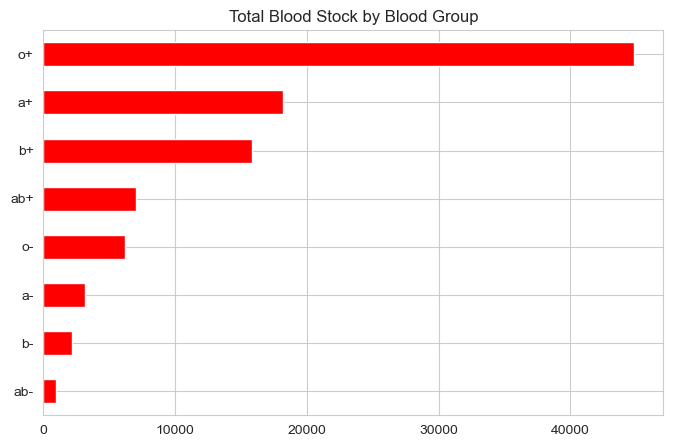

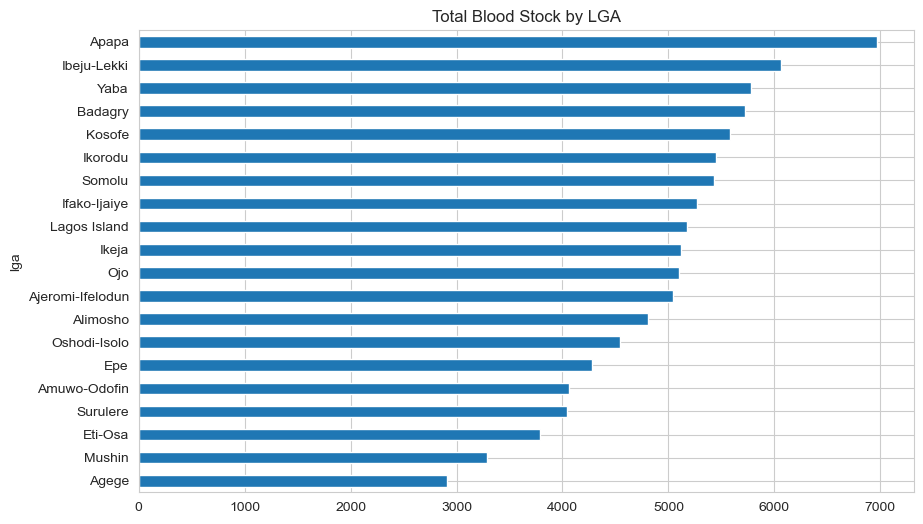

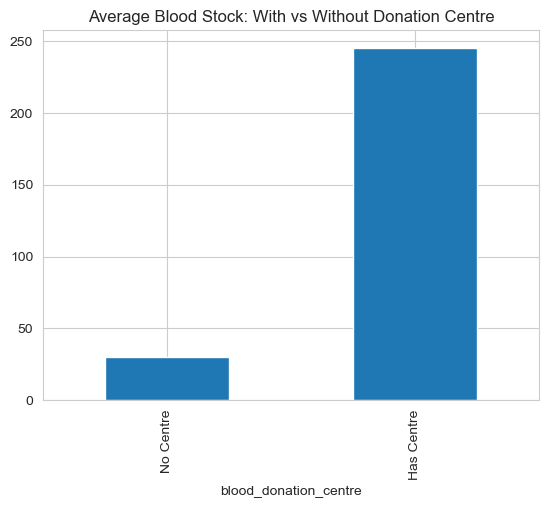

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# 1. Blood stock by blood group - see what's most scarce
blood_cols = ['a+', 'a-', 'b+', 'b-', 'ab+', 'ab-', 'o+', 'o-']
blood_totals = hospitals[blood_cols].sum().sort_values()
blood_totals.plot(kind='barh', figsize=(8,5), color='red')
plt.title('Total Blood Stock by Blood Group')
plt.show()

# 2. Total blood stock by LGA - see which areas are underserved
hospitals['total_blood_stock'] = hospitals[blood_cols].sum(axis=1)
hospitals.groupby('lga')['total_blood_stock'].sum().sort_values().plot(kind='barh', figsize=(10,6))
plt.title('Total Blood Stock by LGA')
plt.show()

# 3. Do donation centres help?
hospitals.groupby('blood_donation_centre')['total_blood_stock'].mean().plot(kind='bar')
plt.title('Average Blood Stock: With vs Without Donation Centre')
plt.xticks([0,1], ['No Centre', 'Has Centre'])
plt.show()

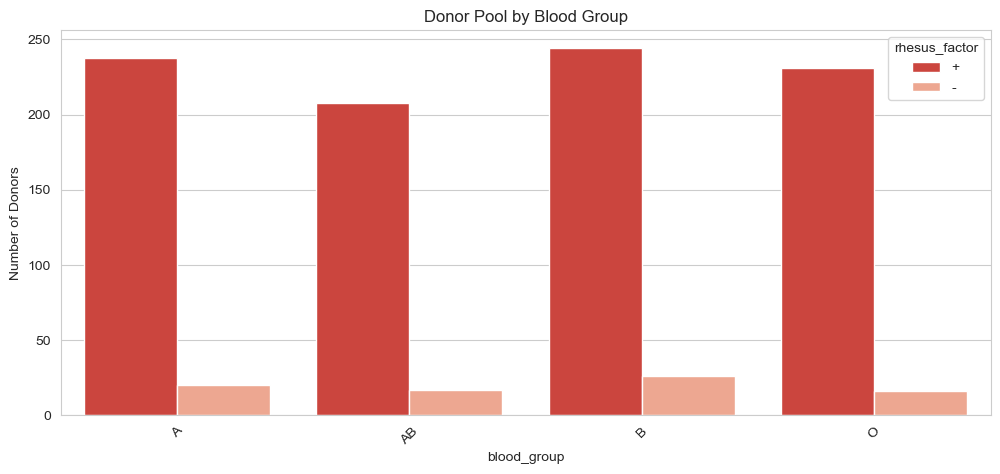

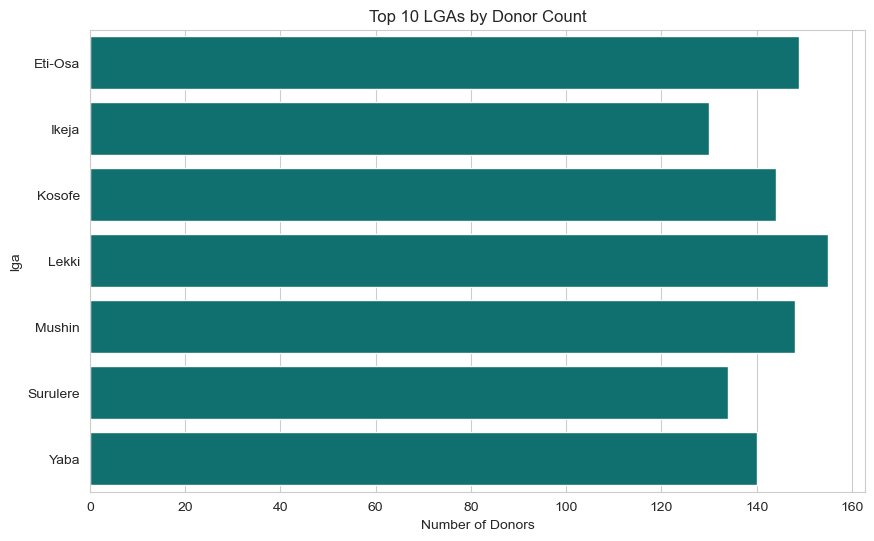

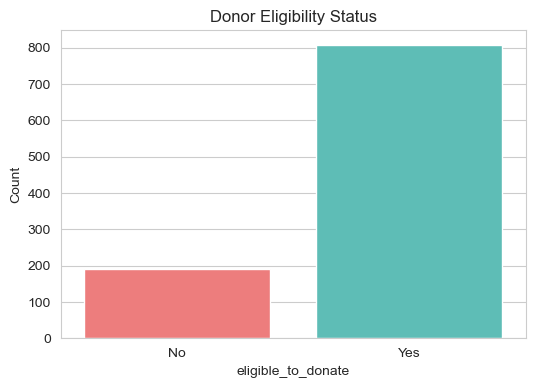

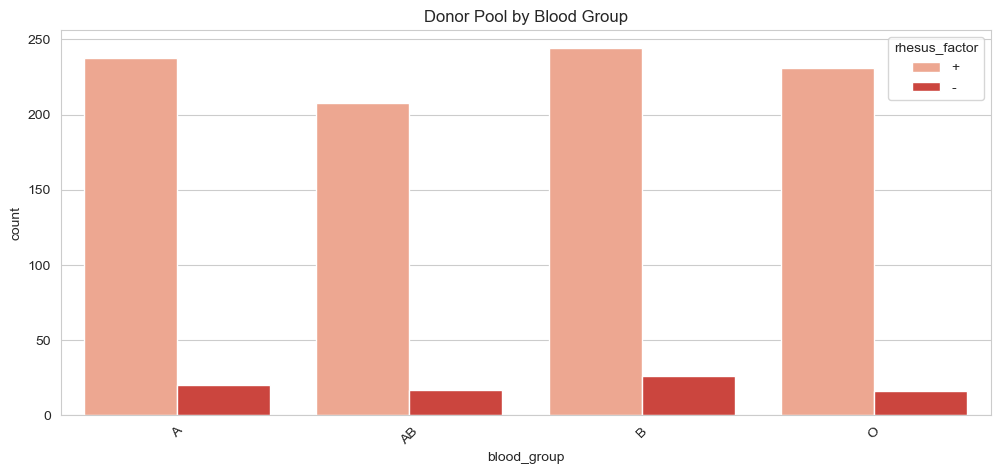

In [25]:
# 1. Blood Supply Base: Donors by Blood Group + Rhesus
plt.figure(figsize=(12,5))
sns.countplot(data=donors, x='blood_group', hue='rhesus_factor', palette='Reds_r')
plt.title('Donor Pool by Blood Group')
plt.xticks(rotation=45)
plt.ylabel('Number of Donors')
plt.show()

# 2. Geography: Top 10 LGAs by Donor Count
plt.figure(figsize=(10,6))
top_lga = donors['lga'].value_counts().head(10)
sns.barplot(x=top_lga.values, y=top_lga.index, color='#008080') # teal hex code
plt.title('Top 10 LGAs by Donor Count')
plt.xlabel('Number of Donors')
plt.show()

# 3. Eligibility Bottleneck - fixed colors
plt.figure(figsize=(6,4))
sns.countplot(data=donors, x='eligible_to_donate', palette=['#FF6B6B','#4ECDC4'])
plt.title('Donor Eligibility Status')
plt.ylabel('Count')
plt.show()

# Blood Group - use built-in palette
plt.figure(figsize=(12,5))
sns.countplot(data=donors, x='blood_group', hue='rhesus_factor', palette='Reds')
plt.title('Donor Pool by Blood Group')
plt.xticks(rotation=45)
plt.show()

In [26]:
# 1. Reshape hospital data to long format
blood_cols = ['a+', 'a-', 'b+', 'b-', 'ab+', 'ab-', 'o+', 'o-']
hospital_blood = hospitals.melt(id_vars=['lga'], value_vars=blood_cols, 
                                var_name='blood_group', value_name='hospital_stock')
hospital_blood_sum = hospital_blood.groupby(['lga', 'blood_group'])['hospital_stock'].sum().reset_index()

# 2. Get donor count by LGA + blood_group
donor_summary = donors.groupby(['lga', 'blood_group']).size().reset_index(name='donor_count')

# 3. MERGE
supply_demand = pd.merge(donor_summary, hospital_blood_sum, on=['lga', 'blood_group'], how='outer').fillna(0)
supply_demand['stock_gap'] = supply_demand['hospital_stock'] - supply_demand['donor_count']

# 4. Find CRITICAL shortages
critical = supply_demand.sort_values('stock_gap').head(10)
critical

,lga,blood_group,donor_count,hospital_stock,stock_gap
106,Kosofe,B,47.0,0.0,-47.0
128,Mushin,A,45.0,0.0,-45.0
167,Surulere,O,42.0,0.0,-42.0
58,Eti-Osa,B,41.0,0.0,-41.0
127,Lekki,O,41.0,0.0,-41.0
126,Lekki,B,41.0,0.0,-41.0
130,Mushin,B,40.0,0.0,-40.0
176,Yaba,A,40.0,0.0,-40.0
84,Ikeja,A,39.0,0.0,-39.0
107,Kosofe,O,39.0,0.0,-39.0


## Building Intelligent Donor Matching Model

In [27]:
# 1. Creating blood compatibility rules.

compatibility = {
    "O-":["O-", "O+", "A-", "A+", "B-", "B+", "AB-", "AB+"],
    "O+":["O+", "A+", "B+", "AB+"],
    "A-":["A-", "A+", "AB-", "AB+"]
}

In [28]:
# 2.  Filtering compatible donors.

requested = "O+"
eligible = donors[
    donors["blood_group"].isin(
        compatibility[requested]
    )
]

In [29]:
# 4. Removing unavailable donors.

eligible = eligible[
    eligible["eligible_to_donate"]=="Yes"
    ]

In [30]:
donors.head()

,donor_id,age,gender,blood_group,rhesus_factor,lga,availability,health_status,last_donation_date,eligible_to_donate
0,D100000,56,Male,A,-,Mushin,Unavailable,Healthy,2025-03-27,No
1,D100001,46,Male,A,+,Surulere,Unavailable,Healthy,2025-05-29,No
2,D100002,32,Female,O,+,Eti-Osa,Available,Healthy,2026-01-07,Yes
3,D100003,25,Female,A,+,Lekki,Unavailable,Healthy,2026-04-25,No
4,D100004,38,Male,B,-,Ikeja,Available,Healthy,2025-05-31,Yes


In [31]:
# 5. Converting 'available' to numbers
donors["AvailabilityScore"] = donors["eligible_to_donate"].map({
    "Yes": 1,
    "No": 0
}).astype(int)


In [32]:
# 6. Normalizing the distance
hospital_lga = "Mushin"

donors["LocationScore"] = donors["lga"].apply(
    lambda x: 1 if x == hospital_lga else 0
)

#Same lga = 1
#Different lga = 0

In [33]:
# 7. Normalizing previous donations

donors["last_donation_date"] = pd.to_datetime(donors["last_donation_date"])

#get today's date
today = pd.Timestamp.today()

donors["DaysSinceDonation"] = (
    today - donors["last_donation_date"]
).dt.days

In [34]:
donors.head()

,donor_id,age,gender,blood_group,rhesus_factor,lga,availability,health_status,last_donation_date,eligible_to_donate,AvailabilityScore,LocationScore,DaysSinceDonation
0,D100000,56,Male,A,-,Mushin,Unavailable,Healthy,2025-03-27,No,0,1,497
1,D100001,46,Male,A,+,Surulere,Unavailable,Healthy,2025-05-29,No,0,0,434
2,D100002,32,Female,O,+,Eti-Osa,Available,Healthy,2026-01-07,Yes,1,0,211
3,D100003,25,Female,A,+,Lekki,Unavailable,Healthy,2026-04-25,No,0,0,103
4,D100004,38,Male,B,-,Ikeja,Available,Healthy,2025-05-31,Yes,1,0,432


In [35]:
#Creating an eligibility score
#donors wait 56days before next donation

donors["DonationEligibility"] = donors["DaysSinceDonation"].apply(
    lambda x: 1 if x >= 56 else 0
)

In [36]:
# 8. Calculating the final score for DonationEligibility

donors["FinalScore"] = (
    donors["LocationScore"] * 0.5 +
    donors["AvailabilityScore"] * 0.3 +
    donors["DonationEligibility"] * 0.2
)

In [37]:
# 9. Ranking the donors based on their scores

ranked_donors = donors.sort_values(
    by="FinalScore",
    ascending=False
)

ranked_donors.head(10)

,donor_id,age,gender,blood_group,rhesus_factor,lga,availability,health_status,last_donation_date,eligible_to_donate,AvailabilityScore,LocationScore,DaysSinceDonation,DonationEligibility,FinalScore
26,D100026,44,Female,A,+,Mushin,Available,Healthy,2025-06-05,Yes,1,1,427,1,1.0
984,D100984,21,Male,AB,+,Mushin,Available,Healthy,2025-11-17,Yes,1,1,262,1,1.0
33,D100033,24,Female,AB,+,Mushin,Available,Healthy,2025-09-19,Yes,1,1,321,1,1.0
35,D100035,26,Male,B,+,Mushin,Available,Healthy,2025-08-17,Yes,1,1,354,1,1.0
18,D100018,47,Female,A,+,Mushin,Available,Healthy,2025-03-08,Yes,1,1,516,1,1.0
24,D100024,39,Male,B,+,Mushin,Available,Healthy,2026-04-25,Yes,1,1,103,1,1.0
994,D100994,53,Male,A,-,Mushin,Available,Healthy,2025-01-11,Yes,1,1,572,1,1.0
995,D100995,41,Female,A,+,Mushin,Available,Healthy,2025-07-06,Yes,1,1,396,1,1.0
794,D100794,45,Female,B,+,Mushin,Available,Healthy,2025-01-19,Yes,1,1,564,1,1.0
762,D100762,36,Male,A,+,Mushin,Available,Healthy,2025-04-06,Yes,1,1,487,1,1.0


In [38]:
# 10. Selecting the top 5 donors.

top_donors = ranked_donors.head(5)
top_donors

,donor_id,age,gender,blood_group,rhesus_factor,lga,availability,health_status,last_donation_date,eligible_to_donate,AvailabilityScore,LocationScore,DaysSinceDonation,DonationEligibility,FinalScore
26,D100026,44,Female,A,+,Mushin,Available,Healthy,2025-06-05,Yes,1,1,427,1,1.0
984,D100984,21,Male,AB,+,Mushin,Available,Healthy,2025-11-17,Yes,1,1,262,1,1.0
33,D100033,24,Female,AB,+,Mushin,Available,Healthy,2025-09-19,Yes,1,1,321,1,1.0
35,D100035,26,Male,B,+,Mushin,Available,Healthy,2025-08-17,Yes,1,1,354,1,1.0
18,D100018,47,Female,A,+,Mushin,Available,Healthy,2025-03-08,Yes,1,1,516,1,1.0


In [39]:
print(donors.columns.tolist())

['donor_id', 'age', 'gender', 'blood_group', 'rhesus_factor', 'lga', 'availability', 'health_status', 'last_donation_date', 'eligible_to_donate', 'AvailabilityScore', 'LocationScore', 'DaysSinceDonation', 'DonationEligibility', 'FinalScore']
